In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = {
    'Student_ID': [101,102,103,104,105,106,107,108,109,110],
    
    'Study_Hours': [2,4,5,np.nan,8,3,15,6,4,5],
    
    'Attendance_Percentage': [75,80,85,90,95,40,110,88,np.nan,92],
    
    'Marks': [45,50,55,60,95,48,500,65,58,np.nan],
    
    'Gender': ['Male','Female','Female','Male',
               'Female','Male','Male','Female',
               'Fmale','Male']
}

df = pd.DataFrame(data)

df

,Student_ID,Study_Hours,Attendance_Percentage,Marks,Gender
0,101,2.0,75.0,45.0,Male
1,102,4.0,80.0,50.0,Female
2,103,5.0,85.0,55.0,Female
3,104,NaN,90.0,60.0,Male
4,105,8.0,95.0,95.0,Female
5,106,3.0,40.0,48.0,Male
6,107,15.0,110.0,500.0,Male
7,108,6.0,88.0,65.0,Female
8,109,4.0,NaN,58.0,Fmale
9,110,5.0,92.0,NaN,Male


In [6]:
df.isnull().sum()

Student_ID               0
Study_Hours              1
Attendance_Percentage    1
Marks                    1
Gender                   0
dtype: int64

In [7]:
df['Study_Hours'] = df['Study_Hours'].fillna(df['Study_Hours'].mean())

In [8]:
df['Attendance_Percentage'] = df['Attendance_Percentage'].fillna(
    df['Attendance_Percentage'].median()
)

In [9]:
df['Marks'] = df['Marks'].fillna(df['Marks'].mean())

In [11]:
df['Gender'].unique()

array(['Male', 'Female', 'Fmale'], dtype=object)

In [12]:
df['Gender'] = df['Gender'].replace('Fmale', 'Female')

print(df['Gender'].unique())

['Male' 'Female']


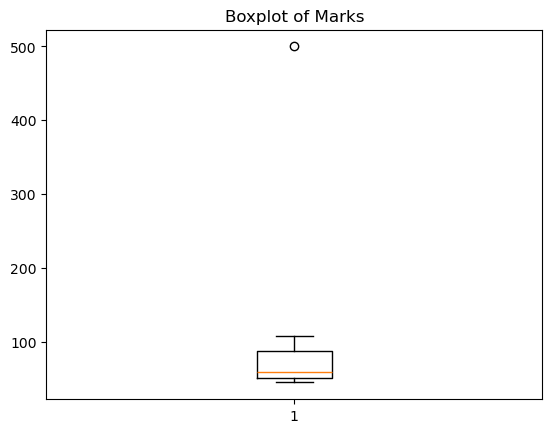

In [14]:
plt.boxplot(df['Marks'])
plt.title("Boxplot of Marks")
plt.show()

In [15]:
Q1 = df['Marks'].quantile(0.25)
Q3 = df['Marks'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -3.125
Upper Limit: 141.875


In [16]:
outliers = df[
    (df['Marks'] < lower_limit) |
    (df['Marks'] > upper_limit)
]

print(outliers)

   Student_ID  Study_Hours  Attendance_Percentage  Marks Gender
6         107         15.0                  110.0  500.0   Male


In [17]:
median_marks = df['Marks'].median()

df['Marks'] = np.where(
    df['Marks'] > upper_limit,
    median_marks,
    df['Marks']
)

print(df)

   Student_ID  Study_Hours  Attendance_Percentage       Marks  Gender
0         101     2.000000                   75.0   45.000000    Male
1         102     4.000000                   80.0   50.000000  Female
2         103     5.000000                   85.0   55.000000  Female
3         104     5.777778                   90.0   60.000000    Male
4         105     8.000000                   95.0   95.000000  Female
5         106     3.000000                   40.0   48.000000    Male
6         107    15.000000                  110.0   59.000000    Male
7         108     6.000000                   88.0   65.000000  Female
8         109     4.000000                   88.0   58.000000  Female
9         110     5.000000                   92.0  108.444444    Male


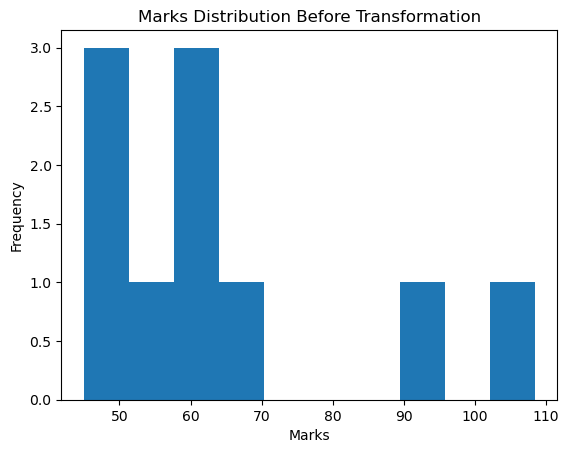

In [18]:
plt.hist(df['Marks'])
plt.title("Marks Distribution Before Transformation")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

In [19]:
df['Log_Marks'] = np.log(df['Marks'] + 1)

print(df[['Marks', 'Log_Marks']])

        Marks  Log_Marks
0   45.000000   3.828641
1   50.000000   3.931826
2   55.000000   4.025352
3   60.000000   4.110874
4   95.000000   4.564348
5   48.000000   3.891820
6   59.000000   4.094345
7   65.000000   4.189655
8   58.000000   4.077537
9  108.444444   4.695417


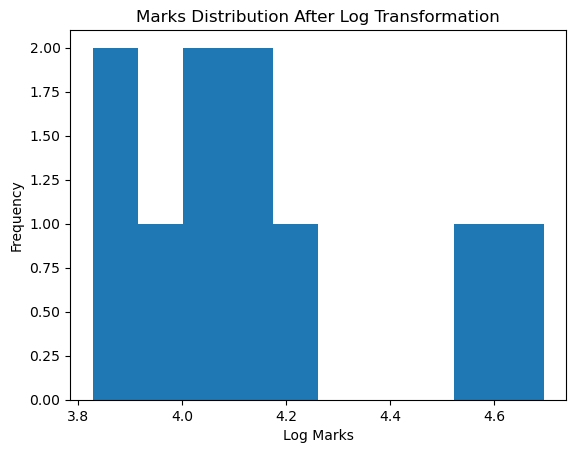

In [20]:
plt.hist(df['Log_Marks'])
plt.title("Marks Distribution After Log Transformation")
plt.xlabel("Log Marks")
plt.ylabel("Frequency")
plt.show()

In [21]:
print(df)

   Student_ID  Study_Hours  Attendance_Percentage       Marks  Gender  \
0         101     2.000000                   75.0   45.000000    Male   
1         102     4.000000                   80.0   50.000000  Female   
2         103     5.000000                   85.0   55.000000  Female   
3         104     5.777778                   90.0   60.000000    Male   
4         105     8.000000                   95.0   95.000000  Female   
5         106     3.000000                   40.0   48.000000    Male   
6         107    15.000000                  110.0   59.000000    Male   
7         108     6.000000                   88.0   65.000000  Female   
8         109     4.000000                   88.0   58.000000  Female   
9         110     5.000000                   92.0  108.444444    Male   

   Log_Marks  
0   3.828641  
1   3.931826  
2   4.025352  
3   4.110874  
4   4.564348  
5   3.891820  
6   4.094345  
7   4.189655  
8   4.077537  
9   4.695417  
